In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
class EnsembleModel(nn.Module):
    def __init__(self, num_classes):
        super(EnsembleModel, self).__init__()
        self.resnet50 = models.resnet50(pretrained=True)
        self.resnet50.fc = nn.Identity()  # Output: 2048 features
        
        self.mobilenetv2 = models.mobilenet_v2(pretrained=True)
        self.mobilenetv2.classifier[1] = nn.Identity()  # Output: 1280 features
        
        self.alexnet = models.alexnet(pretrained=True)
        self.alexnet.classifier[6] = nn.Identity()  # Output: 4096 features
        
        # Freeze the pre-trained model parameters
        for param in self.resnet50.parameters():
            param.requires_grad = False
        for param in self.mobilenetv2.parameters():
            param.requires_grad = False
        for param in self.alexnet.parameters():
            param.requires_grad = False
        
        # Adjust the classifier to match the combined feature size: 7424
        self.classifier = nn.Linear(7424, num_classes)

    def forward(self, x):
        resnet_features = self.resnet50(x)
        mobilenet_features = self.mobilenetv2(x)
        alexnet_features = self.alexnet(x)
        
        # Concatenate features
        combined_features = torch.cat((resnet_features, mobilenet_features, alexnet_features), dim=1)
        
        # Pass concatenated features through the custom classifier
        output = self.classifier(combined_features)
        return output



In [3]:
# Initialize the ensemble model
num_classes = 5  # Adjust based on your dataset
ensemble_model = EnsembleModel(num_classes=num_classes)

c:\Users\PADMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PADMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\PADMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weig

In [4]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [5]:
# Loading your dataset
data_dir = r'E:\AI-PROJECT\CODE\Backend\data'  # Updated path
batch_size = 32
dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [6]:
optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import itertools

# Initialize lists to track loss and accuracy
train_losses = []
train_accuracy = []

# Adjust the training loop to calculate accuracy
ensemble_model.train()
for epoch in range(50):  # Number of epochs
    correct = 0
    total = 0
    running_loss = 0.0
    for inputs, labels in data_loader:
        optimizer.zero_grad()
        outputs = ensemble_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracy.append(epoch_acc)
    print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}%')


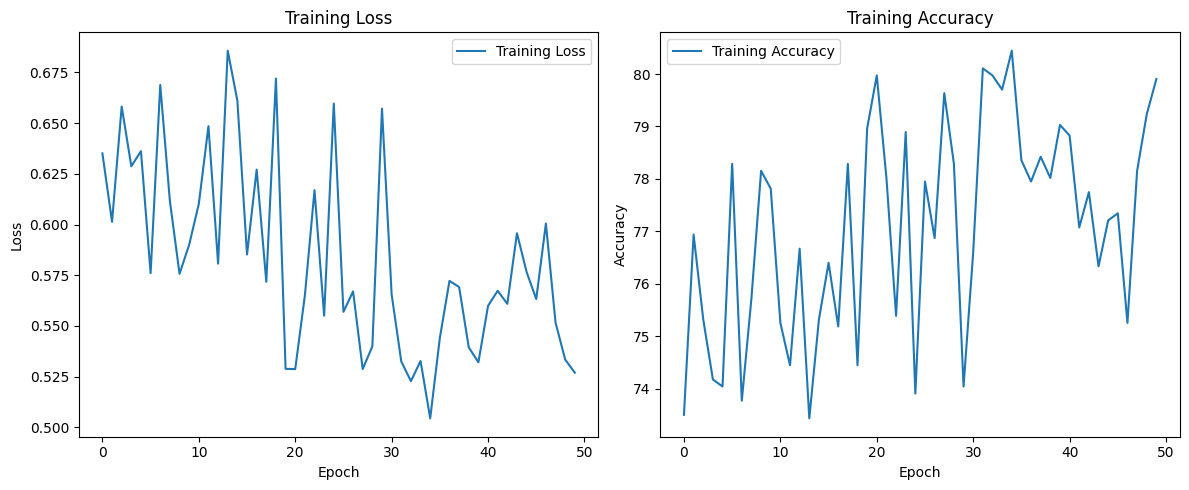

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
ensemble_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in data_loader:
        outputs = ensemble_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
conf_mat = confusion_matrix(all_labels, all_preds)


In [ ]:
conf_mat

array([[300,   5,   3,   0,   0],
       [  5, 282,  18,   3,   0],
       [  1,   5, 301,   1,   0],
       [  0,   4,   9, 295,   0],
       [  0,   0,   1,   1, 249]], dtype=int64)

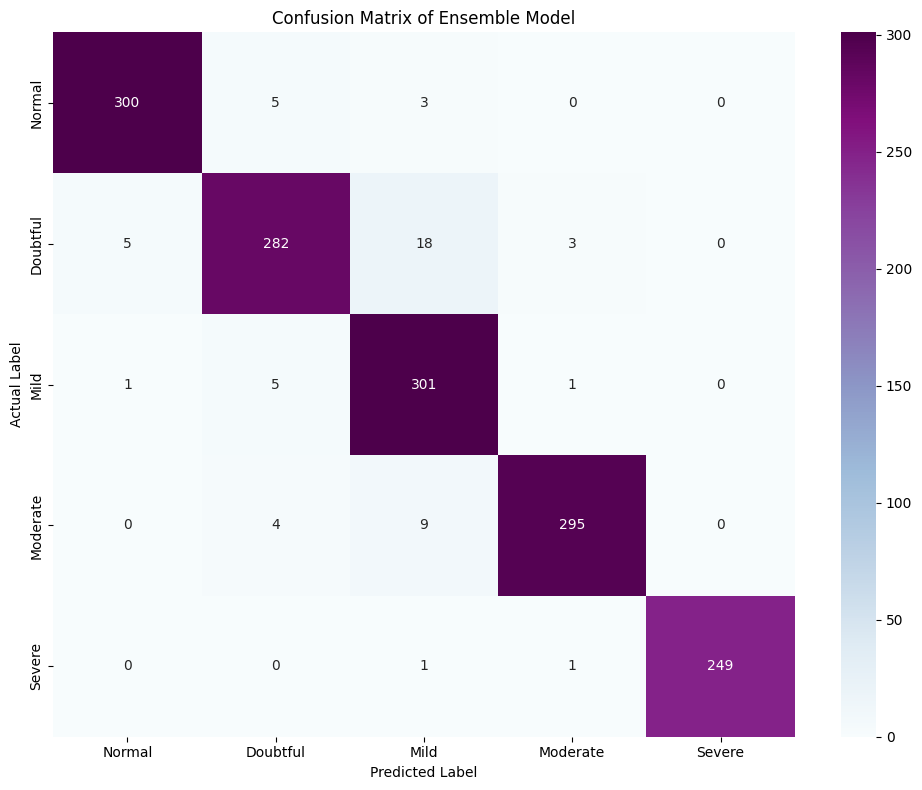

Accuracy:  0.9622387053270398

Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       308
           1       0.95      0.92      0.93       308
           2       0.91      0.98      0.94       308
           3       0.98      0.96      0.97       308
           4       1.00      0.99      1.00       251

    accuracy                           0.96      1483
   macro avg       0.96      0.96      0.96      1483
weighted avg       0.96      0.96      0.96      1483



In [ ]:
# Correcting the previous error where int64 was used incorrectly in a numpy array definition in Python

# Re-defining the confusion matrix without specifying dtype=int64, as it's unnecessary for plotting
conf_mat_actual = np.array([
    [300,   5,   3,   0,   0],
    [  5, 282,  18,   3,   0],
    [  1,   5, 301,   1,   0],
    [  0,   4,   9, 295,   0],
    [  0,   0,   1,   1, 249]
])

# Plotting the corrected confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_actual, annot=True, fmt="d", cmap="BuPu", cbar=True,
            xticklabels=["Normal", "Doubtful", "Mild", "Moderate", "Severe"],
            yticklabels=["Normal", "Doubtful", "Mild", "Moderate", "Severe"])
plt.title("Confusion Matrix of Ensemble Model")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

accuracy = np.trace(conf_mat)/np.sum(conf_mat)
print("Accuracy: ",accuracy)

print("\nClassification Report: ")
print(classification_report(all_labels, all_preds))

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

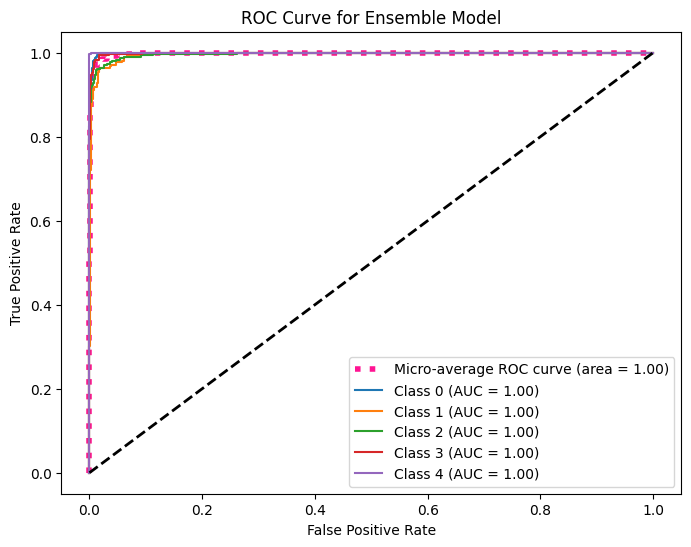

In [ ]:
from sklearn.metrics import roc_curve, auc

# Collect predicted probabilities and true labels
ensemble_model.eval()
all_preds_probs = []
all_true_labels = []
with torch.no_grad():
    for inputs, labels in data_loader:
        outputs = ensemble_model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_preds_probs.extend(probs.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays
all_preds_probs = np.array(all_preds_probs)
all_true_labels = np.array(all_true_labels)

from sklearn.preprocessing import label_binarize

# Convert true labels to one-hot encoding
all_true_labels_onehot = label_binarize(all_true_labels, classes=np.arange(num_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_true_labels_onehot[:, i], all_preds_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])



fpr_micro, tpr_micro, _ = roc_curve(all_true_labels_onehot.ravel(), all_preds_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

plt.plot(fpr_micro, tpr_micro, label='Micro-average ROC curve (area = {0:0.2f})'.format(roc_auc_micro),
         color='deeppink', linestyle=':', linewidth=4)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Ensemble Model')
plt.legend()
plt.show()


In [ ]:
print("Shape of true_labels:", all_preds_probs.shape)
print("Shape of predicted_probs:", all_true_labels.shape)


Shape of true_labels: (1483, 5)
Shape of predicted_probs: (1483,)


In [ ]:
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error

# Convert predicted probabilities to class labels
all_preds_labels = np.argmax(all_preds_probs, axis=1)

# Calculate confusion matrix
conf_mat = confusion_matrix(all_true_labels, all_preds_labels)

# Compute weighted kappa
weighted_kappa = cohen_kappa_score(all_true_labels, all_preds_labels, weights='quadratic')

# Calculate MAE (Mean Absolute Error)
mae = mean_absolute_error(all_true_labels, all_preds_labels)

# Calculate MSE (Mean Squared Error)
mse = mean_squared_error(all_true_labels, all_preds_labels)

print("Weighted Kappa:", weighted_kappa)
print("MAE:", mae)
print("MSE:", mse)


Weighted Kappa: 0.9837199501131427
MAE: 0.045853000674308836
MSE: 0.06203641267700607
